In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.models import resnet18
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import os

# Download FER2013 dataset (if needed)
# !wget https://data.deepai.org/fer2013.zip && unzip fer2013.zip -d fer2013

# Data preprocessing
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((48, 48)),  # FER2013 images are 48x48
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
])


In [ ]:

!unzip fer2013.zip -d fer2013
import shutil

# Define paths
data_dir = 'fer2013'
train_dir = os.path.join(data_dir, 'train')
test_dir = os.path.join(data_dir, 'test')

# Classes to remove
classes_to_remove = ['disgust', 'neutral', 'surprise']

# Function to delete unwanted class folders
def remove_classes(data_dir, classes_to_remove):
    for cls in classes_to_remove:
        class_path_train = os.path.join(train_dir, cls)
        class_path_test = os.path.join(test_dir, cls)
        if os.path.exists(class_path_train):
            shutil.rmtree(class_path_train)
            print(f"Removed training class: {cls}")
        if os.path.exists(class_path_test):
            shutil.rmtree(class_path_test)
            print(f"Removed testing class: {cls}")

# Remove unwanted classes
remove_classes(data_dir, classes_to_remove)

# Define transformations
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((48, 48)),  # FER2013 images are 48x48
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
])

# Reload the filtered dataset
train_dataset = ImageFolder(root=train_dir, transform=transform)
test_dataset = ImageFolder(root=test_dir, transform=transform)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Streaming output truncated to the last 5000 lines.
  inflating: fer2013/train/sad/Training_65338797.jpg  
  inflating: fer2013/train/sad/Training_65387162.jpg  
  inflating: fer2013/train/sad/Training_65404494.jpg  
  inflating: fer2013/train/sad/Training_65426218.jpg  
  inflating: fer2013/train/sad/Training_65430136.jpg  
  inflating: fer2013/train/sad/Training_65437377.jpg  
  inflating: fer2013/train/sad/Training_6545735.jpg  
  inflating: fer2013/train/sad/Training_65463385.jpg  
  inflating: fer2013/train/sad/Training_65473985.jpg  
  inflating: fer2013/train/sad/Training_65502829.jpg  
  inflating: fer2013/train/sad/Training_65505359.jpg  
  inflating: fer2013/train/sad/Training_65508578.jpg  
  inflating: fer2013/train/sad/Training_65516023.jpg  
  inflating: fer2013/train/sad/Training_65524027.jpg  
  inflating: fer2013/train/sad/Training_65526454.jpg  
  inflating: fer2013/train/sad/Training_65531175.jpg  
  inflating: fer2013/train/sad/Training_65552921.jpg  
  inflating: fe

In [ ]:

# Attention Mechanism (Channel-based SE Block)
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        batch, channels, _, _ = x.size()
        y = torch.mean(x.view(batch, channels, -1), dim=2)
        y = self.fc(y).view(batch, channels, 1, 1)
        return x * y


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet18

# Contrastive Loss Function
def contrastive_loss(anchor, positive, negative, margin=1.0):
    pos_dist = (anchor - positive).pow(2).sum(1)
    neg_dist = (anchor - negative).pow(2).sum(1)
    return torch.mean(F.relu(pos_dist - neg_dist + margin))

# MultiScaleBlock for Multi-Scale Feature Extraction
class MultiScaleBlock(nn.Module):
    def __init__(self, channels):
        super(MultiScaleBlock, self).__init__()
        self.conv3 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(channels, channels, kernel_size=5, padding=2)
        self.conv7 = nn.Conv2d(channels, channels, kernel_size=7, padding=3)

    def forward(self, x):
        x3 = self.conv3(x)
        x5 = self.conv5(x)
        x7 = self.conv7(x)
        return x3 + x5 + x7  # Combine multi-scale features

# Attention Block
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        batch, channels, _, _ = x.size()
        y = torch.mean(x.view(batch, channels, -1), dim=2)
        y = self.fc(y).view(batch, channels, 1, 1)
        return x * y

# Updated Emotion Classifier with Multi-Scale and Contrastive Loss Integration
class EmotionClassifierWithAttention(nn.Module):
    def __init__(self, num_classes=4):
        super(EmotionClassifierWithAttention, self).__init__()
        # Shared feature extractor
        base_model = resnet18(pretrained=True)

        # Modify the first convolutional layer to accept 1 channel input
        base_model.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)

        self.feature_extractor = nn.Sequential(*list(base_model.children())[:-2])  # Exclude FC layer

        # Multi-Scale Block for feature refinement
        self.multi_scale_block = MultiScaleBlock(512)

        # Attention for each region
        self.se_block_eyes = SEBlock(512)
        self.se_block_mouth = SEBlock(512)
        self.se_block_eyebrows = SEBlock(512)

        # Fully connected layer
        self.fc = nn.Sequential(
            nn.Linear(3072, 256),  # Use 3072 as the input size
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        batch_size, _, _, _ = x.size()

        # Divide image into regions (simplified for FER2013; no landmarks)
        eyes = x[:, :, :24, :]  # Top half for eyes
        mouth = x[:, :, 24:, :]  # Bottom half for mouth
        eyebrows = x[:, :, :16, :]  # Top quarter for eyebrows

        # Shared feature extraction
        eyes_features = self.feature_extractor(eyes)
        mouth_features = self.feature_extractor(mouth)
        eyebrows_features = self.feature_extractor(eyebrows)

        # Apply multi-scale block to each region
        eyes_features = self.multi_scale_block(eyes_features)
        mouth_features = self.multi_scale_block(mouth_features)
        eyebrows_features = self.multi_scale_block(eyebrows_features)

        # Apply attention to each region
        eyes_attention = self.se_block_eyes(eyes_features)
        mouth_attention = self.se_block_mouth(mouth_features)
        eyebrows_attention = self.se_block_eyebrows(eyebrows_features)

        # Flatten and concatenate features
        eyes_flat = torch.flatten(eyes_attention, 1)
        mouth_flat = torch.flatten(mouth_attention, 1)
        eyebrows_flat = torch.flatten(eyebrows_attention, 1)
        combined_features = torch.cat([eyes_flat, mouth_flat, eyebrows_flat], dim=1)

        # Classification
        output = self.fc(combined_features)
        return output


In [ ]:
class EmotionClassifierWithAttention(nn.Module):
    def __init__(self, num_classes=4):
        super(EmotionClassifierWithAttention, self).__init__()
        base_model = resnet18(pretrained=True)
        base_model.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        self.feature_extractor = nn.Sequential(*list(base_model.children())[:-2])  # Exclude FC layer

        self.multi_scale_block = MultiScaleBlock(512)

        self.se_block_eyes = SEBlock(512)
        self.se_block_mouth = SEBlock(512)
        self.se_block_eyebrows = SEBlock(512)

        self.fc = nn.Sequential(
            nn.Linear(3072, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x, return_embeddings=False):
        batch_size, _, _, _ = x.size()

        eyes = x[:, :, :24, :]
        mouth = x[:, :, 24:, :]
        eyebrows = x[:, :, :16, :]

        eyes_features = self.feature_extractor(eyes)
        mouth_features = self.feature_extractor(mouth)
        eyebrows_features = self.feature_extractor(eyebrows)

        eyes_features = self.multi_scale_block(eyes_features)
        mouth_features = self.multi_scale_block(mouth_features)
        eyebrows_features = self.multi_scale_block(eyebrows_features)

        eyes_attention = self.se_block_eyes(eyes_features)
        mouth_attention = self.se_block_mouth(mouth_features)
        eyebrows_attention = self.se_block_eyebrows(eyebrows_features)

        eyes_flat = torch.flatten(eyes_attention, 1)
        mouth_flat = torch.flatten(mouth_attention, 1)
        eyebrows_flat = torch.flatten(eyebrows_attention, 1)
        combined_features = torch.cat([eyes_flat, mouth_flat, eyebrows_flat], dim=1)

        if return_embeddings:
            return combined_features  # Return embeddings for Contrastive Loss

        output = self.fc(combined_features)
        return output


In [ ]:

# Instantiate the model
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = EmotionClassifierWithAttention(num_classes=4)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 179MB/s]


In [ ]:
def train_model(model, train_loader, test_loader, criterion, optimizer, epochs=10, verbose=1):
    model.train()
    best_accuracy = 0.0
    best_model_weights = None

    # Track metrics for plotting
    train_losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []
    weights_history = []
    biases_history = []

    for epoch in range(epochs):
        running_loss = 0.0
        correct_predictions = 0
        total_samples = 0

        for i, (images, labels) in enumerate(train_loader):
            images, labels = images, labels  

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            # Calculate batch accuracy
            _, predicted = torch.max(outputs, 1)
            correct_predictions += (predicted == labels).sum().item()
            total_samples += labels.size(0)

        # End of epoch logging
        epoch_accuracy = 100 * correct_predictions / total_samples
        train_losses.append(running_loss / len(train_loader))
        train_accuracies.append(epoch_accuracy)
        print(f"Epoch [{epoch+1}/{epochs}], Training Loss: {running_loss/len(train_loader):.4f}, Training Accuracy: {epoch_accuracy:.2f}%")

        # Save weights and biases for plotting
        for name, param in model.named_parameters():
            if param.requires_grad:
                if "weight" in name:
                    weights_history.append(param.detach().cpu().numpy().flatten())
                elif "bias" in name:
                    biases_history.append(param.detach().cpu().numpy().flatten())

        # Testing step
        test_loss, test_accuracy = test_model(model, test_loader, criterion)
        test_losses.append(test_loss)
        test_accuracies.append(test_accuracy)
        print(f"Epoch [{epoch+1}/{epochs}], Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")

        if test_accuracy > best_accuracy:
            best_accuracy = test_accuracy
            best_model_weights = model.state_dict()
            print(f"New best model found at epoch {epoch+1} with accuracy {test_accuracy:.2f}%. Saving model weights.")

    # Save the best model weights to a file
    if best_model_weights is not None:
        torch.save(best_model_weights, "best_model_weights.pth")
        print("Best model weights saved to 'best_model_weights.pth'.")
    else:
        print("No improvement during training. Model weights not saved.")

    return train_losses, test_losses, train_accuracies, test_accuracies, weights_history, biases_history

def test_model(model, test_loader, criterion):
    model.eval()
    correct_predictions = 0
    total_samples = 0
    test_loss = 0.0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images, labels  
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct_predictions += (predicted == labels).sum().item()
            total_samples += labels.size(0)

    accuracy = 100 * correct_predictions / total_samples
    return test_loss / len(test_loader), accuracy


In [ ]:
# Evaluation loop
def evaluate_model(model, test_loader): 
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images, labels
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Accuracy: {100 * correct / total:.2f}%")

Epoch [1/10], Training Loss: 1.3712, Training Accuracy: 34.24%
Epoch [1/10], Test Loss: 1.3380, Test Accuracy: 35.52%
New best model found at epoch 1 with accuracy 35.52%. Saving model weights.
Epoch [2/10], Training Loss: 1.3541, Training Accuracy: 35.78%
Epoch [2/10], Test Loss: 1.3579, Test Accuracy: 35.46%
Epoch [3/10], Training Loss: 1.3562, Training Accuracy: 35.83%
Epoch [3/10], Test Loss: 1.3557, Test Accuracy: 35.46%
Epoch [4/10], Training Loss: 1.2902, Training Accuracy: 39.29%
Epoch [4/10], Test Loss: 1.2201, Test Accuracy: 45.29%
New best model found at epoch 4 with accuracy 45.29%. Saving model weights.
Epoch [5/10], Training Loss: 1.1729, Training Accuracy: 45.78%
Epoch [5/10], Test Loss: 1.1902, Test Accuracy: 45.83%
New best model found at epoch 5 with accuracy 45.83%. Saving model weights.
Epoch [6/10], Training Loss: 1.1135, Training Accuracy: 48.18%
Epoch [6/10], Test Loss: 1.1094, Test Accuracy: 49.93%
New best model found at epoch 6 with accuracy 49.93%. Saving mod

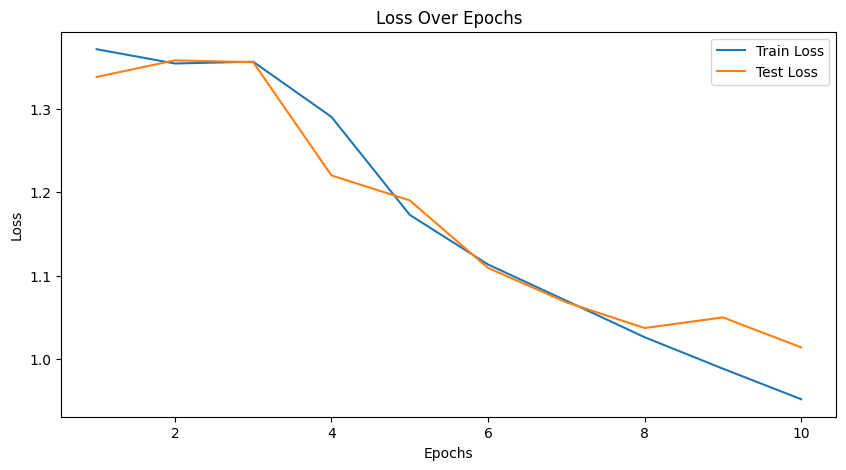

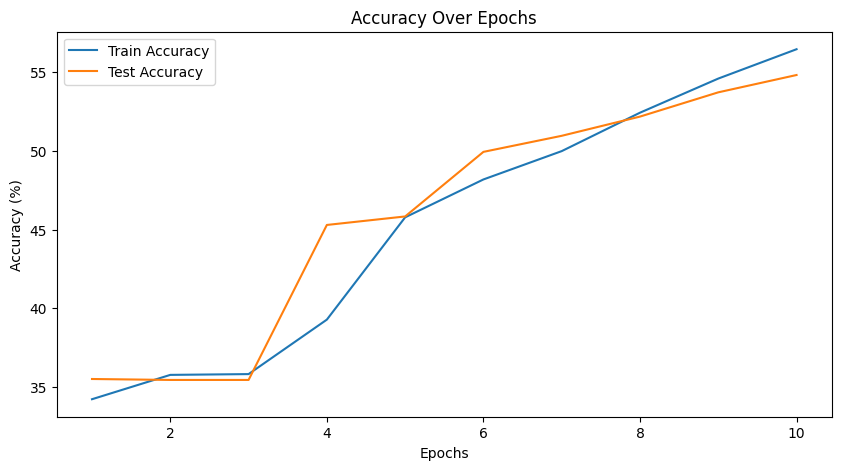

In [ ]:
import matplotlib.pyplot as plt

# Train the model
train_losses, test_losses, train_accuracies, test_accuracies, weights_history, biases_history = train_model(
    model, train_loader, test_loader, criterion, optimizer, epochs=10
)

# Plot training and test loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss")
plt.plot(range(1, len(test_losses) + 1), test_losses, label="Test Loss")
plt.title("Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Plot training and test accuracy
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, label="Train Accuracy")
plt.plot(range(1, len(test_accuracies) + 1), test_accuracies, label="Test Accuracy")
plt.title("Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()


In [ ]:
# Save model weights
torch.save(model.state_dict(), 'best_model_weights.pth')


In [ ]:
evaluate_model(model, test_loader)

Accuracy: 54.81%
